<a href="https://colab.research.google.com/github/BPerkins98/homework/blob/main/Homework3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

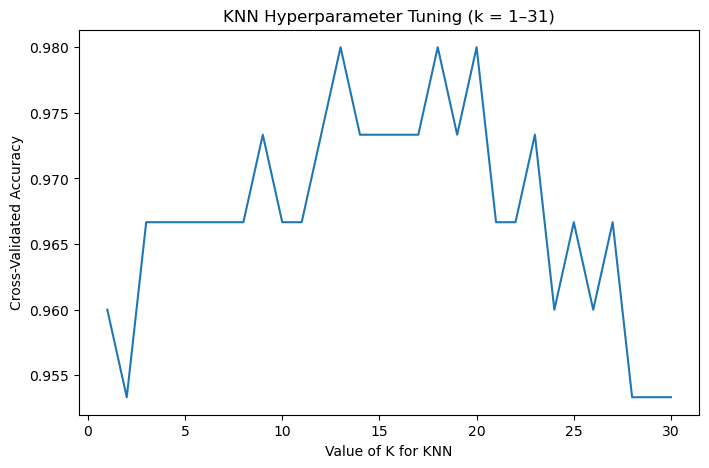

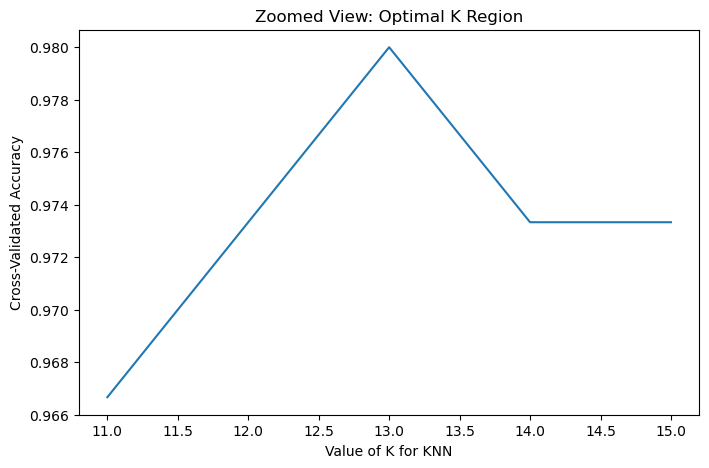

Optimal k from GridSearchCV: 13
Best cross-validated accuracy: 0.9800


In [ ]:
# Ex 15.8: Classification with the Iris Dataset — Hyperparameter Tuning

from sklearn.datasets import load_iris
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, GridSearchCV
import matplotlib.pyplot as plt

# 1️⃣ Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# 2️⃣ Perform 10-fold cross-validation for k = 1 to 31
k_range = range(1, 31)
k_scores = []

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X, y, cv=10)
    k_scores.append(scores.mean())

# 3️⃣ Plot accuracy vs. k (full range)
plt.figure(figsize=(8, 5))
plt.plot(k_range, k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('KNN Hyperparameter Tuning (k = 1–31)')
plt.show()

# 4️⃣ Zoomed-in plot around the optimal region (k = 11–15)
plt.figure(figsize=(8, 5))
plt.plot(range(11, 16), k_scores[10:15])
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.title('Zoomed View: Optimal K Region')
plt.show()

# 5️⃣ Confirm optimal k using GridSearchCV
param_grid = {'n_neighbors': range(1, 31)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=10)
grid.fit(X, y)

print(f"Optimal k from GridSearchCV: {grid.best_params_['n_neighbors']}")
print(f"Best cross-validated accuracy: {grid.best_score_:.4f}")
